<a href="https://colab.research.google.com/github/ErikDlrr/MDatosProyectoFinal/blob/main/Proyecto_Mineria_Datos_Luz_Inteligente_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="text-align:center; padding:30px; border:2px solid #1f4e79; border-radius:12px;">

<h2>Universidad Politécnica de San Luis Potosí</h2>
<h3>Ingeniería en Tecnologías de la Información</h3>
<h3>Minería de Datos</h3>

<br>

<h1>Proyecto Final</h1>
<h2>Reconocimiento de Voz: Luz Inteligente</h2>

<hr>

<p><b>Grupo:</b> 8:00–9:00 PM</p>
<p><b>Fecha de entrega:</b> 25 de mayo de 2026</p>

</div>

<br>

<h2>Integrantes</h2>

<table>
<tr>
<th>Matrícula</th>
<th>Nombre</th>
</tr>
<tr>
<td>177700</td>
<td>Erik De La Rosa Rodríguez</td>
</tr>
<tr>
<td>177301</td>
<td>Leonardo Serrano Zermeño</td>
</tr>
<tr>
<td>__________</td>
<td>__________________________</td>
</tr>
</table>

<br>

<h2>Resumen del proyecto</h2>

<p>
El presente proyecto consiste en el desarrollo de un modelo de red neuronal densa capaz de reconocer comandos de voz para controlar el estado de una luz inteligente.
</p>

<ul>
<li><b>“encender luz”</b> → salida esperada: <code>Luz Encendida</code></li>
<li><b>“apagar luz”</b> → salida esperada: <code>Luz Apagada</code></li>
</ul>

<p>
Para lograrlo, se procesan audios grabados por los alumnos, se extraen características <b>MFCC</b>, se normalizan los datos y se entrenan diferentes arquitecturas de redes neuronales densas para comparar su desempeño.
</p>

# Índice

1. [Introducción teórica](#introducción-teórica)  
2. [Configuración del entorno](#configuración-del-entorno)  
3. [Organización del dataset](#organización-del-dataset)  
4. [Exploración y validación de audios](#exploración-y-validación-de-audios)  
5. [Extracción de características MFCC](#extracción-de-características-mfcc)  
6. [División de datos](#división-de-datos)  
7. [Normalización](#normalización)  
8. [Construcción del modelo](#construcción-del-modelo)  
9. [Experimentación y tuning](#experimentación-y-tuning)  
10. [Evaluación del mejor modelo](#evaluación-del-mejor-modelo)  
11. [Simulación de salida](#simulación-de-salida)  
12. [Prueba ciega con voz del profesor](#prueba-ciega-con-voz-del-profesor)  
13. [Guardado del modelo](#guardado-del-modelo)  
14. [Conclusiones](#conclusiones)  

# Introducción teórica

## Procesamiento de audio

El audio es una señal que varía a lo largo del tiempo. Para que pueda ser procesado por una computadora, el sonido debe convertirse en datos numéricos. En este proyecto, cada grabación de voz se transforma en una representación digital que permite analizar sus características principales.

Debido a que las grabaciones pueden variar en duración, volumen, ruido o cantidad de silencio, es necesario aplicar una etapa de preprocesamiento. Esta etapa permite estandarizar los audios antes de utilizarlos como entrada para el modelo de aprendizaje automático.

El flujo general de procesamiento utilizado es el siguiente:

1. Cargar cada archivo de audio.
2. Convertir la señal a un solo canal de audio.
3. Trabajar con una frecuencia de muestreo uniforme.
4. Eliminar silencios excesivos al inicio o al final de la grabación.
5. Ajustar todos los audios a una duración fija.
6. Extraer características mediante MFCC.
7. Normalizar los valores obtenidos.

Este proceso ayuda a que el modelo reciba datos más consistentes, reduciendo diferencias innecesarias entre grabaciones y enfocándose principalmente en los patrones de voz relevantes para la clasificación.

---

## MFCC

Los **MFCC** (*Mel-Frequency Cepstral Coefficients*) son una técnica utilizada comúnmente en tareas de reconocimiento de voz y procesamiento de audio. Su función es representar una señal sonora mediante un conjunto de coeficientes que resumen información importante sobre el timbre, la energía y la distribución de frecuencias del sonido.

En lugar de utilizar directamente la onda de audio original, cada grabación se convierte en una matriz de características MFCC. Esta representación facilita que el modelo identifique patrones asociados con los comandos de voz.

En este proyecto se utilizan MFCC porque permiten transformar la voz en datos numéricos más compactos y útiles para una red neuronal. De esta manera, el modelo no trabaja con el audio crudo, sino con una versión procesada que conserva información relevante para distinguir entre los comandos **“encender luz”** y **“apagar luz”**.

---

## Redes neuronales densas

Una red neuronal densa es un modelo compuesto por capas de neuronas artificiales. En este tipo de red, cada neurona de una capa se conecta con las neuronas de la capa siguiente, permitiendo que el modelo aprenda relaciones entre los datos de entrada y la salida esperada.

Para este proyecto se utiliza una arquitectura de tipo `Sequential`, adecuada para construir modelos capa por capa. La estructura general del modelo incluye:

- Una capa de entrada para recibir las características extraídas del audio.
- Una capa `Flatten`, encargada de convertir la matriz MFCC en un vector.
- Una o más capas densas ocultas, donde el modelo aprende patrones relevantes.
- Una capa de salida con activación `sigmoid`.

Como el problema consiste en clasificar únicamente dos comandos de voz, se trata de una clasificación binaria. Por esta razón, se utilizan los siguientes elementos:

- **Función de pérdida:** `binary_crossentropy`
- **Métrica de evaluación:** `accuracy`
- **Función de activación de salida:** `sigmoid`

La salida del modelo corresponde a una probabilidad entre `0` y `1`. Con base en ese valor, se interpreta la predicción de la siguiente manera:

- Si la predicción es mayor a `0.5`, el sistema interpreta el comando como **Luz Encendida**.
- Si la predicción es menor o igual a `0.5`, el sistema interpreta el comando como **Luz Apagada**.

Esta lógica permite que el modelo tome una decisión sencilla a partir de la probabilidad generada por la red neuronal.

# Configuración del entorno

En esta sección se instalan e importan las librerías necesarias.

Librerías principales:

- `librosa`: procesamiento de audio y extracción de MFCC.
- `numpy`: operaciones numéricas.
- `tensorflow.keras`: construcción y entrenamiento del modelo.
- `pandas`: manejo de tablas.
- `matplotlib`: gráficas.
- `sklearn`: división de datos y métricas.


In [ ]:
# Instalación de dependencias principales
# En Google Colab, muchas de estas librerías ya vienen instaladas.
# Se dejan estas instrucciones para asegurar compatibilidad.

!pip -q install librosa soundfile


In [ ]:
# Importación de librerías

import os
import re
import math
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.keras.utils.set_random_seed(RANDOM_STATE)

# Montar Google Drive

El dataset debe estar guardado en Google Drive para que Colab pueda acceder a los audios.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Organización del Dataset

**Proyecto:** Reconocimiento de voz para luz inteligente  
**Objetivo:** Mantener los audios ordenados para facilitar el entrenamiento, prueba y evaluación del modelo.

---

## Estructura del proyecto en Google Drive

Para trabajar correctamente en Google Colab, se recomienda organizar los archivos dentro de una carpeta principal en Google Drive. Esta estructura permite separar los audios de entrenamiento, los audios de prueba y los resultados generados durante el proyecto.

```text
Mi unidad/
└── Proyecto_Luz_Inteligente/
    ├── dataset/
    │   ├── encender_luz/
    │   │   ├── alumno01_rep01_encender.wav
    │   │   ├── alumno01_rep02_encender.wav
    │   │   └── ...
    │   │
    │   └── apagar_luz/
    │       ├── alumno01_rep01_apagar.wav
    │       ├── alumno01_rep02_apagar.wav
    │       └── ...
    │
    ├── prueba_ciega/
    │   └── audio_profesor.wav
    │
    └── resultados/
```

---

## Descripción de carpetas

| Carpeta | Uso dentro del proyecto |
|---|---|
| `dataset/` | Contiene los audios utilizados para entrenar el modelo. |
| `encender_luz/` | Guarda las grabaciones correspondientes al comando **“encender luz”**. |
| `apagar_luz/` | Guarda las grabaciones correspondientes al comando **“apagar luz”**. |
| `prueba_ciega/` | Contiene audios externos que no forman parte del entrenamiento. Sirve para probar el modelo con grabaciones nuevas. |
| `resultados/` | Puede utilizarse para guardar gráficas, métricas, modelos entrenados y evidencias del proyecto. |

---

## Reglas para la grabación de audios

Para que el modelo pueda aprender patrones de voz de forma más confiable, las grabaciones deben realizarse bajo condiciones similares. La calidad y organización del dataset influyen directamente en el desempeño del modelo.

Se recomienda seguir estas reglas:

- Grabar los audios con celular o con un micrófono funcional.
- Realizar las grabaciones en un lugar sin música, ruido fuerte o interrupciones.
- Pronunciar la frase completa de forma clara.
- Evitar cortar el audio antes de terminar la frase.
- Mantener una duración aproximada de **1 a 3 segundos** por grabación.
- Conservar una distancia similar entre la persona y el micrófono.
- Grabar más de una repetición por comando, si está permitido.
- Usar exactamente las frases **“encender luz”** y **“apagar luz”**.
- Nombrar los archivos de forma ordenada y fácil de identificar.

---

## Ejemplo de nombres recomendados

```text
alumno01_rep01_encender.wav
alumno01_rep02_encender.wav
alumno01_rep01_apagar.wav
alumno01_rep02_apagar.wav
```

---

## Consideraciones sobre los archivos

El formato recomendado para las grabaciones es `.wav`, ya que suele ser más estable para tareas de procesamiento de audio. Aunque algunos códigos también permiten usar archivos `.mp3`, lo más conveniente es trabajar con un solo formato para evitar errores durante la carga del dataset.

> **Importante:**  
> La extensión correcta es `.wav`, no `.waw`.  
> Si algún archivo aparece con la extensión incorrecta, debe revisarse y corregirse antes de ejecutar el procesamiento de datos.

---

## Importancia de una buena organización

Una estructura clara del dataset permite:

- Cargar los audios de forma más sencilla.
- Asignar correctamente las etiquetas de cada clase.
- Evitar errores durante el entrenamiento.
- Facilitar la evaluación con audios externos.
- Hacer que el proyecto sea más ordenado y reproducible.

En resumen, organizar correctamente los archivos no es solo una cuestión estética: también ayuda a que el modelo pueda entrenarse y evaluarse de manera más confiable.

In [ ]:
# Configuración de rutas ajustada a la realidad del Drive
PROJECT_NAME = "Proyecto_Luz_Inteligente"
PROJECT_DIR = f"/content/drive/MyDrive/{PROJECT_NAME}"

# Actualizado: los audios están dentro de la subcarpeta 'Librosa'
DATASET_DIR = os.path.join(PROJECT_DIR, "Librosa")
RESULTS_DIR = os.path.join(PROJECT_DIR, "resultados")
BLIND_TEST_DIR = os.path.join(PROJECT_DIR, "prueba_ciega")

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(BLIND_TEST_DIR, exist_ok=True)

# Ajustamos los nombres de las clases a los nombres de tus carpetas
CLASSES = {
    "apagarluz": 0,
    "encenderluz": 1
}

LABEL_TO_ACTION = {
    0: "Luz Apagada",
    1: "Luz Encendida"
}

print("Carpeta del proyecto:", PROJECT_DIR)
print("Buscando audios en:", DATASET_DIR)
print("Clases detectadas:", list(CLASSES.keys()))

Carpeta del proyecto: /content/drive/MyDrive/Proyecto_Luz_Inteligente
Buscando audios en: /content/drive/MyDrive/Proyecto_Luz_Inteligente/Librosa
Clases detectadas: ['apagarluz', 'encenderluz']


### Acceso a Carpeta Compartida
Como los archivos están en una carpeta compartida, asegúrate de haber creado un **Acceso directo** en tu Google Drive. Luego, usa la siguiente celda para localizar el nombre exacto de la carpeta y actualizar `PROJECT_DIR` si es necesario.

In [ ]:
import os

# Listar las carpetas en tu Drive para encontrar el nombre del acceso directo
mi_unidad_path = "/content/drive/MyDrive/"
if os.path.exists(mi_unidad_path):
    print("Carpetas encontradas en tu Drive:")
    print(os.listdir(mi_unidad_path))
else:
    print("Google Drive no parece estar montado correctamente.")

Carpetas encontradas en tu Drive:
['nose.gdoc', 'Qué es el cerebro.docx', 'Qué es el cerebro.gdoc', 'Classroom', 'EJERCICIOS ELEMENTOS DE LA ORACIÓN.gdoc', 'Simulación CENEVAL.gdoc', 'Certificado para empleados.gslides', 'Portfolio.gslides', 'Excursión.gslides', 'Tu gran idea.gslides', 'avicii-waiting-for-love-instrumental.mp3', 'Minijuego-Tipos de pensamiento.png', 'Actividad - Tipos de pensamiento.pdf', 'Tipos de pensamiento.pdf', 'Reglas ortográficas.gform', 'Minijuego Cit. APA.png', 'Actividad - Ragnarok.png', 'Minijuego - Teoria.png', 'Corrección.gform', 'Minijuego - tutorial.png', 'Minijuego - teoria - referencias APA.png', 'Minijuego2 - teoria - referencias APA.png', 'Actividad - Práctica.png', 'Dinamita - Práctica.png', 'Educaplay 177291.docx', 'Dinamita - Test final.png', 'Suicide squad - Tutorial - 178678.png', 'Feminismo.docx', 'Copia de Rubrica de evaluación referencias.docx', 'Perro panzon - Práctica.png', 'Corrección de texto.gform', 'Programación Web I.gsite

In [ ]:
import os

# Verificar contenido de la carpeta del proyecto para ajustar las rutas
path_to_check = "/content/drive/MyDrive/Proyecto_Luz_Inteligente"
if os.path.exists(path_to_check):
    print(f"Contenido de {path_to_check}:")
    print(os.listdir(path_to_check))

    # Intentar ver si existe 'dataset' y qué hay dentro
    dataset_path = os.path.join(path_to_check, "dataset")
    if os.path.exists(dataset_path):
        print(f"\nContenido de {dataset_path}:")
        print(os.listdir(dataset_path))
else:
    print("La carpeta Proyecto_Luz_Inteligente no se encuentra. Revisa el paso de 'Añadir acceso directo'.")

Contenido de /content/drive/MyDrive/Proyecto_Luz_Inteligente:
['resultados', 'prueba_ciega', 'Librosa']


# Exploración y validación de audios

Antes de entrenar, se revisa que:

- Existan audios para ambas clases.
- Los archivos estén en carpetas correctas.
- Haya equilibrio entre clases.
- Los audios tengan duración razonable.
- Se pueda inferir el identificador del alumno para evitar fuga de datos.

## ¿Por qué separar por alumno?

Si un mismo alumno tiene audios en entrenamiento y prueba, el modelo podría aprender características de su voz y aparentar mejor desempeño. Para evaluar mejor la generalización, intentaremos que los audios de un mismo alumno queden en el mismo conjunto: entrenamiento, validación o prueba.


In [ ]:
AUDIO_EXTENSIONS = {".wav", ".mp3"}

def infer_speaker_id(path):
    """
    Intenta inferir el identificador de la persona a partir del nombre del archivo.
    Ejemplos esperados:
    - alumno01_rep01_encender.wav -> alumno_01
    - a12_apagar.mp3 -> a_12
    - estudiante05_encender.wav -> estudiante_05

    Si no encuentra un patrón claro, usa una versión simplificada del nombre.
    """
    stem_original = Path(path).stem.lower()

    # Buscar patrones explícitos
    pattern = r"(alumno|alumna|estudiante|student|persona|a)[_\-\s]?(\d+)"
    match = re.search(pattern, stem_original)

    if match:
        prefix = match.group(1)
        number = match.group(2).zfill(2)
        return f"{prefix}_{number}"

    # Quitar palabras relacionadas con las clases
    stem = stem_original
    for word in ["encender", "apagar", "luz", "prender", "enciende", "apaga", "on", "off"]:
        stem = stem.replace(word, "")

    # Limpiar separadores
    stem = re.sub(r"[^a-z0-9]+", "_", stem)
    stem = stem.strip("_")

    if stem:
        return stem

    return stem_original


def crear_manifest(dataset_dir):
    rows = []

    for class_name, label in CLASSES.items():
        class_dir = Path(dataset_dir) / class_name

        if not class_dir.exists():
            print(f"Advertencia: no existe la carpeta {class_dir}")
            continue

        for audio_path in sorted(class_dir.rglob("*")):
            if audio_path.is_file() and audio_path.suffix.lower() in AUDIO_EXTENSIONS:
                rows.append({
                    "path": str(audio_path),
                    "filename": audio_path.name,
                    "class_name": class_name,
                    "label": label,
                    "speaker_id": infer_speaker_id(audio_path)
                })

    return pd.DataFrame(rows)


df = crear_manifest(DATASET_DIR)

print("Total de audios encontrados:", len(df))
display(df.head())

assert len(df) > 0, "No se encontraron audios. Revisa la ruta DATASET_DIR y la estructura de carpetas."


Total de audios encontrados: 38


,path,filename,class_name,label,speaker_id
0,/content/drive/MyDrive/Proyecto_Luz_Inteligent...,Apagar Luz(1).wav,apagarluz,0,1
1,/content/drive/MyDrive/Proyecto_Luz_Inteligent...,Apagar Luz.wav,apagarluz,0,apagar luz
2,/content/drive/MyDrive/Proyecto_Luz_Inteligent...,Apagar luz(2).wav,apagarluz,0,2
3,/content/drive/MyDrive/Proyecto_Luz_Inteligent...,Apagar-Luz(1).wav,apagarluz,0,1
4,/content/drive/MyDrive/Proyecto_Luz_Inteligent...,ApagarLuz.wav,apagarluz,0,apagarluz


In [ ]:
# Revisión de archivos con extensión sospechosa .waw

waw_files = list(Path(DATASET_DIR).rglob("*.waw"))

if len(waw_files) > 0:
    print("Se encontraron archivos con extensión .waw. Revisa si deberían ser .wav:")
    for file in waw_files[:20]:
        print(file)
else:
    print("No se encontraron archivos .waw.")


No se encontraron archivos .waw.


,class_name,label,cantidad
0,apagarluz,0,20
1,encenderluz,1,18


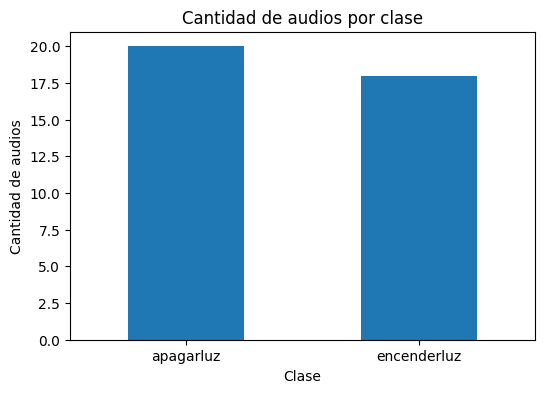

Dataset esperado mínimo según guía: 122 audios
Dataset encontrado: 38
No cumple con el mínimo esperado. Se recomienda recolectar más audios.


In [ ]:
# Conteo por clase

conteo_clases = df.groupby(["class_name", "label"]).size().reset_index(name="cantidad")
display(conteo_clases)

plt.figure(figsize=(6, 4))
df["class_name"].value_counts().plot(kind="bar")
plt.title("Cantidad de audios por clase")
plt.xlabel("Clase")
plt.ylabel("Cantidad de audios")
plt.xticks(rotation=0)
plt.show()

print("Dataset esperado mínimo según guía: 122 audios")
print("Dataset encontrado:", len(df))

if len(df) >= 122:
    print("Cumple con el mínimo esperado.")
else:
    print("No cumple con el mínimo esperado. Se recomienda recolectar más audios.")


/tmp/ipykernel_5382/2369782100.py:5: FutureWarning: PySoundFile failed. Trying audioread instead.
	Audioread support is deprecated in librosa 0.10.0 and will be removed in version 1.0.
  return librosa.get_duration(path=path)
/tmp/ipykernel_5382/2369782100.py:5: FutureWarning: PySoundFile failed. Trying audioread instead.
	Audioread support is deprecated in librosa 0.10.0 and will be removed in version 1.0.
  return librosa.get_duration(path=path)
/tmp/ipykernel_5382/2369782100.py:5: FutureWarning: PySoundFile failed. Trying audioread instead.
	Audioread support is deprecated in librosa 0.10.0 and will be removed in version 1.0.
  return librosa.get_duration(path=path)
/tmp/ipykernel_5382/2369782100.py:5: FutureWarning: PySoundFile failed. Trying audioread instead.
	Audioread support is deprecated in librosa 0.10.0 and will be removed in version 1.0.
  return librosa.get_duration(path=path)


,filename,class_name,speaker_id,duration_sec
0,Apagar Luz(1).wav,apagarluz,1,1.429333
1,Apagar Luz.wav,apagarluz,apagar luz,3.114667
2,Apagar luz(2).wav,apagarluz,2,1.985333
3,Apagar-Luz(1).wav,apagarluz,1,3.388000
4,ApagarLuz.wav,apagarluz,apagarluz,2.368000


Resumen de duración:


,count,mean,std,min,25%,50%,75%,max
class_name,,,,,,,,
apagarluz,20.0,2.523377,0.963579,1.3,1.844333,2.33400,3.007782,5.008979
encenderluz,18.0,2.456190,0.690259,1.3,1.901333,2.45878,2.890667,3.644000


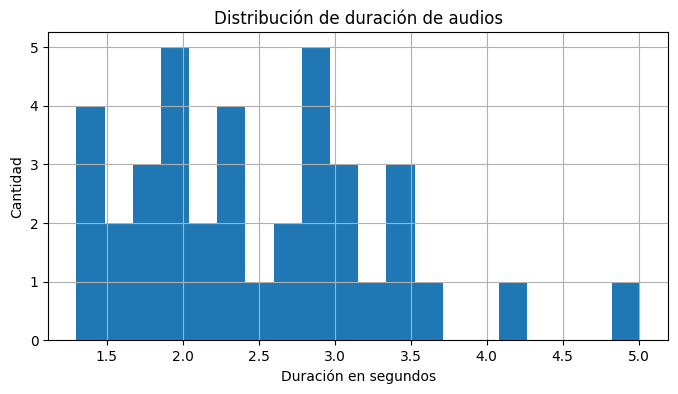

In [ ]:
# Cálculo de duración de audios

def obtener_duracion(path):
    try:
        return librosa.get_duration(path=path)
    except Exception:
        return np.nan

df["duration_sec"] = df["path"].apply(obtener_duracion)

display(df[["filename", "class_name", "speaker_id", "duration_sec"]].head())

print("Resumen de duración:")
display(df.groupby("class_name")["duration_sec"].describe())

plt.figure(figsize=(8, 4))
df["duration_sec"].dropna().hist(bins=20)
plt.title("Distribución de duración de audios")
plt.xlabel("Duración en segundos")
plt.ylabel("Cantidad")
plt.show()


In [ ]:
# Revisión de posibles audios demasiado cortos o largos

audios_problematicos = df[(df["duration_sec"] < 0.5) | (df["duration_sec"] > 5.0)]

print("Audios potencialmente problemáticos:", len(audios_problematicos))
display(audios_problematicos[["filename", "class_name", "duration_sec", "path"]].head(20))


Audios potencialmente problemáticos: 1


,filename,class_name,duration_sec,path
9,LUZ APAGADA.wav,apagarluz,5.008979,/content/drive/MyDrive/Proyecto_Luz_Inteligent...


# Extracción de características MFCC

En esta sección se convierte cada audio en una matriz MFCC.

Parámetros usados:

- `SR = 22050`: frecuencia de muestreo común.
- `DURATION = 2.5`: duración fija de cada audio en segundos.
- `N_MFCC = 40`: número de coeficientes MFCC.
- `HOP_LENGTH = 512`: salto entre ventanas.
- `N_FFT = 2048`: tamaño de ventana para análisis espectral.

Todos los audios se recortan o rellenan para tener la misma duración. Esto permite que todas las matrices tengan el mismo tamaño.


In [ ]:
# Parámetros de procesamiento de audio

SR = 22050
DURATION = 2.5
TARGET_SAMPLES = int(SR * DURATION)

N_MFCC = 40
N_FFT = 2048
HOP_LENGTH = 512

# Número máximo de frames esperado para MFCC
MAX_FRAMES = math.ceil(TARGET_SAMPLES / HOP_LENGTH) + 1

print("SR:", SR)
print("Duración fija:", DURATION, "segundos")
print("Muestras objetivo:", TARGET_SAMPLES)
print("N_MFCC:", N_MFCC)
print("MAX_FRAMES:", MAX_FRAMES)


SR: 22050
Duración fija: 2.5 segundos
Muestras objetivo: 55125
N_MFCC: 40
MAX_FRAMES: 109


## Cargar audio estandar
Esta funcion se encarga de limpiar y normalizar el archivo de audio antes de su procesamiento
Lectura básica: Carga el archivo de la ruta (path), convirtiéndolo a mono (un solo canal, sin estéreo) y forzando una frecuencia de muestreo constante definida en la variable SR.

- Recorte de silencios (librosa.effects.trim): Elimina el "ruido muerto" o los silencios largos que suele haber al principio y al final del audio. Si por alguna razón el audio se queda vacío tras el recorte, conserva el original para no perder el dato.
- Ajuste de duración (Padding o Recorte): Los modelos de Machine Learning necesitan que todos los datos midan lo mismo.
    - Si el audio es más corto que el tamaño objetivo (TARGET_SAMPLES), le añade ceros al final (np.pad) hasta alcanzar la longitud deseada.
    - Si el audio es más largo, lo corta abruptamente al llegar al límite.

## Extraer MFCC
Una vez que el audio esta estandarizado, esta funcion se encarga de extraer los MFCC (Coeficientes Cepstrales en las Frecuencias de Mel)
Los MFCC se encargan de converrtir el audio en una matriz numerica que imita la forma en que el oido humano percibe las diferentes frecuencias de voz.
- Cálculo de características: Usa `librosa.feature.mfcc` para extraer estos coeficientes usando configuraciones previas (`N_MFCC`, `N_FFT`, etc.).
- Asegurar dimensiones fijas: Al igual que con las ondas de audio en el paso anterior, aquí vuelve a verificar que la matriz resultante tenga exactamente el número de columnas (`MAX_FRAMES`) esperado, aplicando de nuevo relleno con ceros (padding) o recorte si es necesario.
- Conversión: Devuelve la matriz en formato float32 (números decimales estándar), que es el formato que mejor procesan las tarjetas gráficas (GPUs) al entrenar modelos.

## Codigo de prueba 
El ultimo bloque de esta seccion sirve para comprobar que todo funciona de manera correcta con un solo ejemplo: 
1. Toma el primer audio de un listado (`df.iloc[0]["path"]`).
2. Le extrae su matriz MFCC.
3. Imprime en consola la ruta del archivo y las dimensiones finales de la matriz (que deberían coincidir exactamente con (`N_MFCC`, `MAX_FRAMES`)).
4. Genera una gráfica (Espectrograma): Dibuja visualmente la matriz MFCC para que puedas ver la intensidad de las frecuencias a lo largo del tiempo en forma de mapa de calor.

Audio de ejemplo: /content/drive/MyDrive/Proyecto_Luz_Inteligente/Librosa/apagarluz/Apagar Luz(1).wav
Forma MFCC: (40, 109)


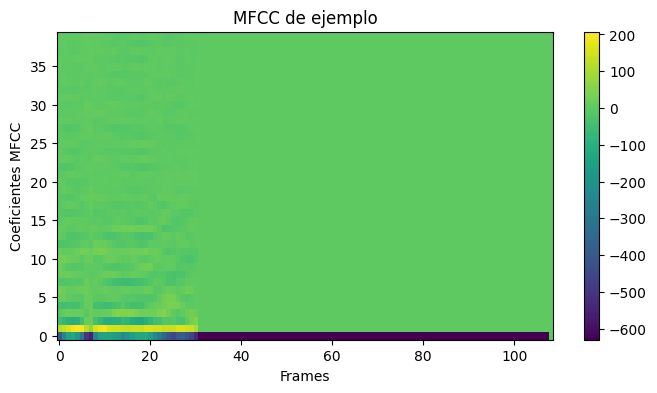

In [ ]:
def cargar_audio_estandar(path):
    """
    Carga un audio y lo estandariza:
    - mono
    - frecuencia de muestreo fija
    - recorte de silencios
    - padding o recorte a duración fija
    """
    y, sr = librosa.load(path, sr=SR, mono=True)

    # Recortar silencios al inicio y al final
    y_trimmed, _ = librosa.effects.trim(y, top_db=25)

    # Si el recorte deja el audio vacío, se usa el original
    if len(y_trimmed) > 0:
        y = y_trimmed

    # Padding o recorte
    if len(y) < TARGET_SAMPLES:
        padding = TARGET_SAMPLES - len(y)
        y = np.pad(y, (0, padding), mode="constant")
    else:
        y = y[:TARGET_SAMPLES]

    return y


def extraer_mfcc(path):
    """
    Extrae MFCC de un audio y asegura tamaño fijo: (N_MFCC, MAX_FRAMES)
    """
    y = cargar_audio_estandar(path)

    mfcc = librosa.feature.mfcc(
        y=y,
        sr=SR,
        n_mfcc=N_MFCC,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH
    )

    # Ajuste por padding o recorte de frames
    if mfcc.shape[1] < MAX_FRAMES:
        pad_width = MAX_FRAMES - mfcc.shape[1]
        mfcc = np.pad(mfcc, ((0, 0), (0, pad_width)), mode="constant")
    elif mfcc.shape[1] > MAX_FRAMES:
        mfcc = mfcc[:, :MAX_FRAMES]

    return mfcc.astype(np.float32)


# Prueba con un audio
sample_path = df.iloc[0]["path"]
sample_mfcc = extraer_mfcc(sample_path)

print("Audio de ejemplo:", sample_path)
print("Forma MFCC:", sample_mfcc.shape)

plt.figure(figsize=(8, 4))
plt.imshow(sample_mfcc, aspect="auto", origin="lower")
plt.title("MFCC de ejemplo")
plt.xlabel("Frames")
plt.ylabel("Coeficientes MFCC")
plt.colorbar()
plt.show()

## Construccion de la matriz X y el vector Y
Este codigo tiene el objetivo de procesar en lote (batch) todos los audios de la base de datos (`df`) utilizando la funcion `extraer_mfcc` que fue definida previamente, organizando todos los resultados en las estructuras de datos que una Inteligencia Artificial necesita para su entrenamiento: la matriz de caracteristicas (X) y el vector de etiquetas (Y)
Ademas, tiene un sistema anti-fallos muy util:
1. Preparacion y bucle "a prueba de errores": 
    El codigo crea varias listas vacias para ir guardando la informacion y recorre el DataFrame fila por fila (`df.iterrows()`), mientras que el bloque de `try/except` anota que archivos son validos y cuales no, con el proposito de no detener la ejecucion del programa.
2. Construccion de los datos finales: 
    Una vez que se sabe que todos los datos son validos, las listas son transformadas en listas de objetos de NumPy y Pandas.
3. Resumen y reporte de errores: 
    Al final, el codigo imprime un resumen en donde muestra las dimensiones de los conjuntos de datos finales, asi como la cantidad de audios que fueron ejecutados correctamente y cuantos tienen erorres o estan corruptos, mostrando las primeras 20 rutas que fallaron, junto con su respectivo mensaje de error.

In [ ]:
# Construcción de la matriz X y el vector y

X_list = []
y_list = []
valid_rows = []
failed_files = []

for _, row in df.iterrows():
    try:
        mfcc = extraer_mfcc(row["path"])
        X_list.append(mfcc)
        y_list.append(row["label"])
        valid_rows.append(row)
    except Exception as e:
        failed_files.append({
            "path": row["path"],
            "error": str(e)
        })

X = np.stack(X_list).astype(np.float32)
y = np.array(y_list).astype(np.float32)
df_valid = pd.DataFrame(valid_rows).reset_index(drop=True)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Audios procesados correctamente:", len(df_valid))
print("Audios con error:", len(failed_files))

if failed_files:
    display(pd.DataFrame(failed_files).head(20))


/tmp/ipykernel_5382/1252523288.py:9: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=SR, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_5382/1252523288.py:9: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=SR, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_5382/1252523288.py:9: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=SR, mono=True)
/usr/local/lib/python3.12/dist-pa

X shape: (38, 40, 109)
y shape: (38,)
Audios procesados correctamente: 38
Audios con error: 0


# División de datos

Se dividen los datos en:

- **70% entrenamiento**
- **15% validación**
- **15% prueba**

Cuando sea posible, se hace una división por `speaker_id`, para evitar que la misma persona aparezca en entrenamiento y prueba.


In [ ]:
def split_por_grupo_o_estratificado(df_valid, y, test_total_size=0.30):
    """
    Intenta dividir por grupos de hablante.
    Si no hay suficientes grupos o falla la división, usa división estratificada por clase.
    """
    indices = np.arange(len(df_valid))
    groups = df_valid["speaker_id"].values

    try:
        unique_groups = np.unique(groups)

        if len(unique_groups) >= 10:
            # 70% train, 30% temporal
            gss1 = GroupShuffleSplit(
                n_splits=1,
                test_size=test_total_size,
                random_state=RANDOM_STATE
            )

            train_idx, temp_idx = next(gss1.split(indices, y, groups))

            # 15% validation, 15% test a partir del 30% temporal
            temp_groups = groups[temp_idx]
            temp_y = y[temp_idx]

            gss2 = GroupShuffleSplit(
                n_splits=1,
                test_size=0.50,
                random_state=RANDOM_STATE
            )

            val_rel_idx, test_rel_idx = next(gss2.split(temp_idx, temp_y, temp_groups))

            val_idx = temp_idx[val_rel_idx]
            test_idx = temp_idx[test_rel_idx]

            return train_idx, val_idx, test_idx, "División por hablante usando speaker_id"

        else:
            raise ValueError("No hay suficientes hablantes únicos para GroupShuffleSplit.")

    except Exception as e:
        print("No se pudo usar división por hablante. Motivo:", e)
        print("Se usará división estratificada por clase.")

        train_idx, temp_idx = train_test_split(
            indices,
            test_size=test_total_size,
            random_state=RANDOM_STATE,
            stratify=y
        )

        val_idx, test_idx = train_test_split(
            temp_idx,
            test_size=0.50,
            random_state=RANDOM_STATE,
            stratify=y[temp_idx]
        )

        return train_idx, val_idx, test_idx, "División estratificada por clase"


train_idx, val_idx, test_idx, split_method = split_por_grupo_o_estratificado(df_valid, y)

print("Método usado:", split_method)
print("Train:", len(train_idx))
print("Validation:", len(val_idx))
print("Test:", len(test_idx))

df_valid["split"] = "sin_asignar"
df_valid.loc[train_idx, "split"] = "train"
df_valid.loc[val_idx, "split"] = "validation"
df_valid.loc[test_idx, "split"] = "test"

display(pd.crosstab(df_valid["split"], df_valid["class_name"]))


Método usado: División por hablante usando speaker_id
Train: 20
Validation: 3
Test: 15


class_name,apagarluz,encenderluz
split,,
test,7,8
train,12,8
validation,1,2


In [ ]:
# Verificación de hablantes por conjunto

speaker_split = df_valid.groupby("speaker_id")["split"].nunique().reset_index()
speaker_split.columns = ["speaker_id", "num_splits"]

leakage = speaker_split[speaker_split["num_splits"] > 1]

if len(leakage) == 0:
    print("No se detectó el mismo speaker_id en varios conjuntos.")
else:
    print("Advertencia: algunos speaker_id aparecen en más de un conjunto.")
    display(leakage.head(20))


No se detectó el mismo speaker_id en varios conjuntos.


# Normalización

La normalización se calcula usando **solo los datos de entrenamiento** para evitar fuga de información.

Se usa normalización Min-Max al rango `[-1, 1]`, como pide la guía del proyecto.


In [ ]:
X_train = X[train_idx]
X_val = X[val_idx]
X_test = X[test_idx]

y_train = y[train_idx]
y_val = y[val_idx]
y_test = y[test_idx]

# Parámetros de normalización calculados solo con entrenamiento
X_min = X_train.min()
X_max = X_train.max()

def normalizar_mfcc(X_data):
    X_norm = 2 * (X_data - X_min) / (X_max - X_min + 1e-8) - 1
    X_norm = np.clip(X_norm, -1, 1)
    return X_norm.astype(np.float32)

X_train_norm = normalizar_mfcc(X_train)
X_val_norm = normalizar_mfcc(X_val)
X_test_norm = normalizar_mfcc(X_test)

print("Rango entrenamiento normalizado:", X_train_norm.min(), X_train_norm.max())
print("Rango validación normalizado:", X_val_norm.min(), X_val_norm.max())
print("Rango prueba normalizado:", X_test_norm.min(), X_test_norm.max())


Rango entrenamiento normalizado: -1.0 1.0
Rango validación normalizado: -0.9029455 0.8755381
Rango prueba normalizado: -1.0 0.92937386


# Construcción del modelo

La arquitectura usa:

- `Input`: define la forma de entrada.
- `Flatten`: convierte la matriz MFCC en vector.
- Capas densas ocultas con activación `relu`.
- `Dropout` opcional para reducir sobreajuste.
- Capa de salida con `sigmoid`.

La salida representa la probabilidad de que el comando sea **“encender luz”**.


In [ ]:
def crear_modelo(input_shape, hidden_layers=(64, 32), dropout=0.2, learning_rate=0.001):
    """
    Crea un modelo Sequential de red neuronal densa.
    """
    model = keras.Sequential(name="modelo_luz_inteligente")

    model.add(keras.Input(shape=input_shape, name="entrada_mfcc"))
    model.add(layers.Flatten(name="flatten"))

    for i, units in enumerate(hidden_layers, start=1):
        model.add(layers.Dense(units, activation="relu", name=f"densa_{i}_{units}"))

        if dropout > 0:
            model.add(layers.Dropout(dropout, name=f"dropout_{i}"))

    model.add(layers.Dense(1, activation="sigmoid", name="salida_sigmoide"))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


input_shape = X_train_norm.shape[1:]
modelo_base = crear_modelo(input_shape=input_shape, hidden_layers=(64, 32), dropout=0.2)
modelo_base.summary()


Model: "modelo_luz_inteligente"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 4360)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densa_1_64 (Dense)              │ (None, 64)             │       279,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densa_2_32 (Dense)              │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida_sigmoide (Dense)         │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 281,217 (1.07 MB)

 Trainable params: 281,217 (1.07 MB)

 Non-trainable params: 0 (0.00 B)

# Experimentación y tuning

Se prueban varias arquitecturas para encontrar un equilibrio entre precisión y simplicidad.

La comparación incluye:

- Número de capas ocultas.
- Neuronas por capa.
- Dropout.
- Número de parámetros.
- Accuracy en validación.
- Loss en validación.
- Accuracy en prueba.

**Criterio de selección:** se elige el modelo con mejor desempeño en validación. Si hay empate, se prefiere el modelo más simple.


In [ ]:
experimentos = [
    {
        "nombre": "M1_1capa_32",
        "capas": (32,),
        "dropout": 0.0
    },
    {
        "nombre": "M2_1capa_64",
        "capas": (64,),
        "dropout": 0.1
    },
    {
        "nombre": "M3_2capas_64_32",
        "capas": (64, 32),
        "dropout": 0.2
    },
    {
        "nombre": "M4_2capas_128_64",
        "capas": (128, 64),
        "dropout": 0.2
    },
    {
        "nombre": "M5_3capas_128_64_32",
        "capas": (128, 64, 32),
        "dropout": 0.3
    }
]

EPOCHS = 100
BATCH_SIZE = 8

histories = {}
models = {}
results = []

for cfg in experimentos:
    print("=" * 80)
    print("Entrenando:", cfg["nombre"])
    print("Capas:", cfg["capas"], "| Dropout:", cfg["dropout"])

    model = crear_modelo(
        input_shape=input_shape,
        hidden_layers=cfg["capas"],
        dropout=cfg["dropout"],
        learning_rate=0.001
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=12,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_norm,
        y_train,
        validation_data=(X_val_norm, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop],
        verbose=0
    )

    train_loss, train_acc = model.evaluate(X_train_norm, y_train, verbose=0)
    val_loss, val_acc = model.evaluate(X_val_norm, y_val, verbose=0)
    test_loss, test_acc = model.evaluate(X_test_norm, y_test, verbose=0)

    best_epoch = int(np.argmin(history.history["val_loss"]) + 1)

    histories[cfg["nombre"]] = history
    models[cfg["nombre"]] = model

    results.append({
        "modelo": cfg["nombre"],
        "capas_ocultas": str(cfg["capas"]),
        "dropout": cfg["dropout"],
        "parametros": model.count_params(),
        "best_epoch": best_epoch,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "val_loss": val_loss,
        "val_accuracy": val_acc,
        "test_loss": test_loss,
        "test_accuracy": test_acc
    })

results_df = pd.DataFrame(results)
results_df_sorted = results_df.sort_values(
    by=["val_accuracy", "val_loss", "parametros"],
    ascending=[False, True, True]
).reset_index(drop=True)

display(results_df_sorted)


Entrenando: M1_1capa_32
Capas: (32,) | Dropout: 0.0
Entrenando: M2_1capa_64
Capas: (64,) | Dropout: 0.1
Entrenando: M3_2capas_64_32
Capas: (64, 32) | Dropout: 0.2
Entrenando: M4_2capas_128_64
Capas: (128, 64) | Dropout: 0.2
Entrenando: M5_3capas_128_64_32
Capas: (128, 64, 32) | Dropout: 0.3


,modelo,capas_ocultas,dropout,parametros,best_epoch,train_loss,train_accuracy,val_loss,val_accuracy,test_loss,test_accuracy
0,M2_1capa_64,"(64,)",0.1,279169,5,0.785207,0.4,0.613153,0.666667,0.713283,0.533333
1,M5_3capas_128_64_32,"(128, 64, 32)",0.3,568577,8,0.812061,0.4,0.633076,0.666667,0.722901,0.533333
2,M4_2capas_128_64,"(128, 64)",0.2,566529,1,0.872669,0.4,0.639349,0.666667,0.757319,0.533333
3,M3_2capas_64_32,"(64, 32)",0.2,281217,6,0.705752,0.4,0.677646,0.666667,0.688944,0.533333
4,M1_1capa_32,"(32,)",0.0,139585,3,0.693286,0.4,0.692229,0.666667,0.693101,0.533333


In [ ]:
# Selección del mejor modelo según validación

best_model_name = results_df_sorted.iloc[0]["modelo"]
best_model = models[best_model_name]
best_history = histories[best_model_name]

print("Mejor modelo seleccionado:", best_model_name)
display(results_df_sorted.iloc[[0]])


Mejor modelo seleccionado: M2_1capa_64


,modelo,capas_ocultas,dropout,parametros,best_epoch,train_loss,train_accuracy,val_loss,val_accuracy,test_loss,test_accuracy
0,M2_1capa_64,"(64,)",0.1,279169,5,0.785207,0.4,0.613153,0.666667,0.713283,0.533333


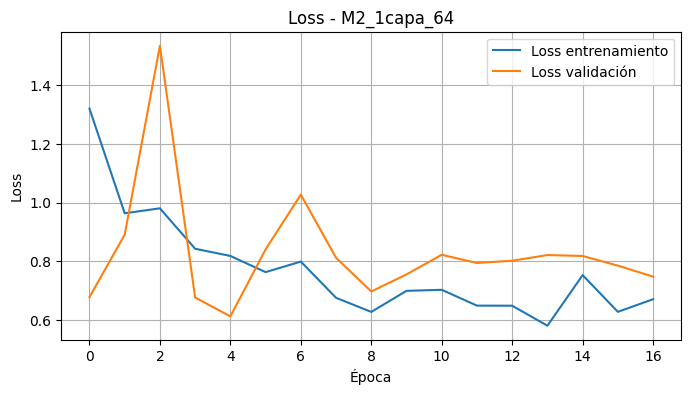

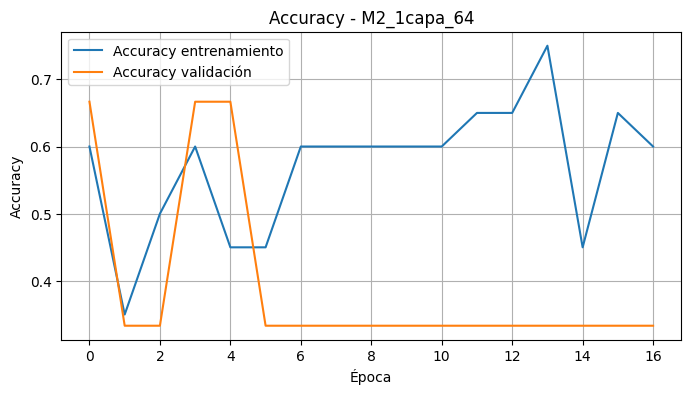

In [ ]:
# Gráficas de loss y accuracy del mejor modelo

def graficar_historial(history, title="Modelo"):
    plt.figure(figsize=(8, 4))
    plt.plot(history.history["loss"], label="Loss entrenamiento")
    plt.plot(history.history["val_loss"], label="Loss validación")
    plt.title(f"Loss - {title}")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(history.history["accuracy"], label="Accuracy entrenamiento")
    plt.plot(history.history["val_accuracy"], label="Accuracy validación")
    plt.title(f"Accuracy - {title}")
    plt.xlabel("Época")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()


graficar_historial(best_history, best_model_name)


# Evaluación del mejor modelo

En esta sección se evalúa el modelo seleccionado usando el conjunto de prueba.

Se reportan:

- Accuracy.
- Matriz de confusión.
- Reporte de clasificación.
- Errores detectados.


Loss en prueba: 0.713283121585846
Accuracy en prueba: 0.5333333611488342
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step

Reporte de clasificación:
              precision    recall  f1-score   support

  apagar_luz       0.00      0.00      0.00         7
encender_luz       0.53      1.00      0.70         8

    accuracy                           0.53        15
   macro avg       0.27      0.50      0.35        15
weighted avg       0.28      0.53      0.37        15



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


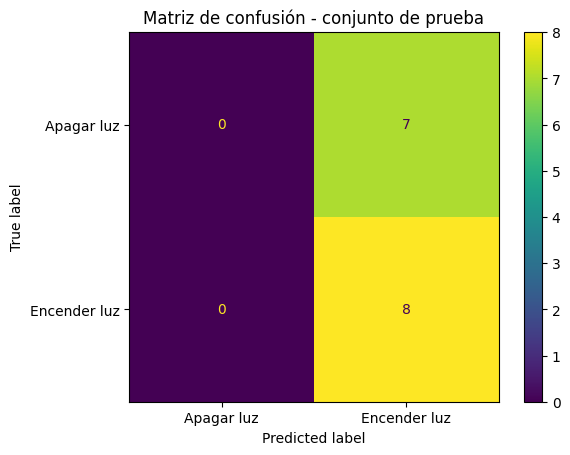

In [ ]:
# Evaluación final en test

test_loss, test_acc = best_model.evaluate(X_test_norm, y_test, verbose=0)

print("Loss en prueba:", test_loss)
print("Accuracy en prueba:", test_acc)

y_prob_test = best_model.predict(X_test_norm).ravel()
y_pred_test = (y_prob_test > 0.5).astype(int)

print("\nReporte de clasificación:")
print(classification_report(
    y_test.astype(int),
    y_pred_test,
    target_names=["apagar_luz", "encender_luz"]
))

cm = confusion_matrix(y_test.astype(int), y_pred_test, labels=[0, 1])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Apagar luz", "Encender luz"]
)

disp.plot()
plt.title("Matriz de confusión - conjunto de prueba")
plt.show()


In [ ]:
# Revisión de predicciones incorrectas

df_test = df_valid.iloc[test_idx].copy().reset_index(drop=True)
df_test["prob_encender"] = y_prob_test
df_test["pred_label"] = y_pred_test
df_test["pred_action"] = df_test["pred_label"].map(LABEL_TO_ACTION)
df_test["real_action"] = df_test["label"].astype(int).map(LABEL_TO_ACTION)
df_test["correcto"] = df_test["pred_label"] == df_test["label"].astype(int)

errores = df_test[df_test["correcto"] == False]

print("Total de errores en prueba:", len(errores))
display(errores[["filename", "class_name", "real_action", "prob_encender", "pred_action", "path"]])


Total de errores en prueba: 7


,filename,class_name,real_action,prob_encender,pred_action,path
0,Apagar Luz(1).wav,apagarluz,Luz Apagada,0.636510,Luz Encendida,/content/drive/MyDrive/Proyecto_Luz_Inteligent...
1,Apagar-Luz(1).wav,apagarluz,Luz Apagada,0.635531,Luz Encendida,/content/drive/MyDrive/Proyecto_Luz_Inteligent...
2,Apagar_Luz_18.wav,apagarluz,Luz Apagada,0.644396,Luz Encendida,/content/drive/MyDrive/Proyecto_Luz_Inteligent...
3,apagar1.wav,apagarluz,Luz Apagada,0.655322,Luz Encendida,/content/drive/MyDrive/Proyecto_Luz_Inteligent...
4,apagar_luz (1).wav,apagarluz,Luz Apagada,0.653147,Luz Encendida,/content/drive/MyDrive/Proyecto_Luz_Inteligent...
5,apagar_luz(1).wav,apagarluz,Luz Apagada,0.628243,Luz Encendida,/content/drive/MyDrive/Proyecto_Luz_Inteligent...
6,apagarluz(1).wav,apagarluz,Luz Apagada,0.646569,Luz Encendida,/content/drive/MyDrive/Proyecto_Luz_Inteligent...


# Simulación de salida

La lógica solicitada por el proyecto es:

```text
Si predicción > 0.5 → Luz Encendida
Si predicción < 0.5 → Luz Apagada
```

En este notebook se interpreta la salida de la red de la siguiente forma:

- Probabilidad cercana a `1`: mayor confianza en **encender luz**.
- Probabilidad cercana a `0`: mayor confianza en **apagar luz**.


In [ ]:
def interpretar_prediccion(probabilidad):
    if probabilidad > 0.5:
        return "Luz Encendida"
    else:
        return "Luz Apagada"


def predecir_audio(path, model=best_model):
    mfcc = extraer_mfcc(path)
    mfcc = np.expand_dims(mfcc, axis=0)
    mfcc_norm = normalizar_mfcc(mfcc)

    prob = float(model.predict(mfcc_norm, verbose=0).ravel()[0])
    accion = interpretar_prediccion(prob)

    return prob, accion


# Simulación con algunos audios del conjunto de prueba
for i in range(min(5, len(df_test))):
    row = df_test.iloc[i]
    prob, accion = predecir_audio(row["path"], best_model)
    print("Archivo:", row["filename"])
    print("Etiqueta real:", row["real_action"])
    print("Probabilidad de encender:", round(prob, 4))
    print("Salida simulada:", accion)
    print("-" * 60)


Archivo: Apagar Luz(1).wav
Etiqueta real: Luz Apagada
Probabilidad de encender: 0.6365
Salida simulada: Luz Encendida
------------------------------------------------------------
Archivo: Apagar-Luz(1).wav
Etiqueta real: Luz Apagada
Probabilidad de encender: 0.6355
Salida simulada: Luz Encendida
------------------------------------------------------------
Archivo: Apagar_Luz_18.wav
Etiqueta real: Luz Apagada
Probabilidad de encender: 0.6444
Salida simulada: Luz Encendida
------------------------------------------------------------


/tmp/ipykernel_5382/1252523288.py:9: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=SR, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Archivo: apagar1.wav
Etiqueta real: Luz Apagada
Probabilidad de encender: 0.6553
Salida simulada: Luz Encendida
------------------------------------------------------------
Archivo: apagar_luz (1).wav
Etiqueta real: Luz Apagada
Probabilidad de encender: 0.6531
Salida simulada: Luz Encendida
------------------------------------------------------------


# Prueba ciega con voz del profesor

El profesor probará el modelo en vivo. Se ofrecen dos opciones:

1. **Subir un archivo de audio** grabado con celular o computadora.
2. **Grabar directamente en Colab** desde el navegador.

La opción más estable suele ser subir un archivo `.wav` o `.mp3`.


In [2]:
# Opción A: subir archivo de audio manualmente

from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():
    print("Archivo subido:", filename)

    prob, accion = predecir_audio(filename, best_model)

    print("Probabilidad de 'encender luz':", round(prob, 4))
    print("Predicción final:", accion)


KeyboardInterrupt: 

In [ ]:
# Opción B: grabar audio directamente en Colab
# Puede requerir permiso del navegador para usar el micrófono.

from IPython.display import Javascript, display, Audio
from google.colab import output
from base64 import b64decode
import subprocess

RECORD_AUDIO_JS = """
async function recordAudio(seconds) {
    const sleep = time => new Promise(resolve => setTimeout(resolve, time));
    const stream = await navigator.mediaDevices.getUserMedia({audio: true});
    const mediaRecorder = new MediaRecorder(stream);

    let chunks = [];
    mediaRecorder.ondataavailable = event => chunks.push(event.data);
    mediaRecorder.start();

    await sleep(seconds * 1000);

    mediaRecorder.stop();
    await new Promise(resolve => mediaRecorder.onstop = resolve);

    stream.getTracks().forEach(track => track.stop());

    const blob = new Blob(chunks, {type: 'audio/webm'});
    const reader = new FileReader();
    reader.readAsDataURL(blob);

    return await new Promise(resolve => {
        reader.onloadend = () => resolve(reader.result);
    });
}
"""

def grabar_audio_colab(segundos=3, salida_wav="audio_profesor_colab.wav"):
    display(Javascript(RECORD_AUDIO_JS))

    data = output.eval_js(f"recordAudio({segundos})")
    binary = b64decode(data.split(",")[1])

    webm_path = salida_wav.replace(".wav", ".webm")

    with open(webm_path, "wb") as f:
        f.write(binary)

    subprocess.run(
        ["ffmpeg", "-y", "-i", webm_path, salida_wav],
        check=True,
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL
    )

    return salida_wav


audio_grabado = grabar_audio_colab(segundos=3, salida_wav="audio_profesor_colab.wav")
display(Audio(audio_grabado))

prob, accion = predecir_audio(audio_grabado, best_model)

print("Probabilidad de 'encender luz':", round(prob, 4))
print("Predicción final:", accion)


# Guardado del modelo

Se guarda:

- El mejor modelo entrenado.
- Los parámetros de normalización.
- La tabla de resultados de experimentos.
- El manifest del dataset procesado.

Esto permite reutilizar el modelo posteriormente sin volver a entrenar desde cero.


In [ ]:
# Guardar modelo y resultados

model_path = os.path.join(RESULTS_DIR, "modelo_luz_inteligente.keras")
norm_path = os.path.join(RESULTS_DIR, "normalizacion_mfcc.npz")
results_path = os.path.join(RESULTS_DIR, "resultados_experimentos.csv")
manifest_path = os.path.join(RESULTS_DIR, "manifest_dataset_procesado.csv")

best_model.save(model_path)

np.savez(
    norm_path,
    X_min=X_min,
    X_max=X_max,
    SR=SR,
    DURATION=DURATION,
    N_MFCC=N_MFCC,
    N_FFT=N_FFT,
    HOP_LENGTH=HOP_LENGTH,
    MAX_FRAMES=MAX_FRAMES
)

results_df_sorted.to_csv(results_path, index=False)
df_valid.to_csv(manifest_path, index=False)

print("Modelo guardado en:", model_path)
print("Normalización guardada en:", norm_path)
print("Resultados guardados en:", results_path)
print("Manifest guardado en:", manifest_path)


# Justificación técnica

## Justificación del uso de MFCC

Se utilizaron **MFCC** (*Mel-Frequency Cepstral Coefficients*) porque permiten representar una señal de voz mediante un conjunto reducido de características numéricas. En lugar de trabajar directamente con la onda de audio original, los MFCC resumen información relevante sobre el comportamiento espectral del sonido, lo cual facilita la identificación de patrones asociados con la pronunciación de cada comando.

Esta representación es más adecuada para el modelo, ya que reduce la complejidad de los datos de entrada y conserva información útil para diferenciar entre las frases **“encender luz”** y **“apagar luz”**.

---

## Justificación de la red neuronal densa

Se empleó una red neuronal densa porque la guía del proyecto solicita trabajar con una arquitectura basada en capas densas. Este tipo de red permite aprender relaciones entre las características extraídas del audio y la clase correspondiente.

Como los MFCC se obtienen en forma de matriz, fue necesario utilizar una capa `Flatten` para convertir dicha matriz en un vector. De esta manera, los datos pueden ser procesados correctamente por las capas densas del modelo.

La arquitectura general utilizada incluye:

- Una entrada basada en características MFCC.
- Una capa `Flatten` para transformar la matriz en vector.
- Una o más capas densas ocultas.
- Una capa de salida con activación `sigmoid`.

---

## Justificación de la función de pérdida

El problema planteado corresponde a una clasificación binaria, ya que únicamente existen dos clases posibles:

- `encender_luz`
- `apagar_luz`

Por esta razón, se utilizó la función de pérdida `binary_crossentropy`, la cual es adecuada cuando el modelo debe distinguir entre dos clases y la capa de salida utiliza una función de activación `sigmoid`.

La salida del modelo representa una probabilidad entre `0` y `1`, por lo que se puede establecer un umbral de decisión para interpretar el resultado:

- Valores mayores a `0.5`: clase `encender_luz`.
- Valores menores o iguales a `0.5`: clase `apagar_luz`.

---

## Justificación de la arquitectura seleccionada

Después de realizar la fase de experimentación y ajuste de hiperparámetros (*tuning*), se seleccionó el modelo **M2_1capa_64** como la arquitectura más conveniente dentro de las pruebas realizadas.

| Característica | Valor |
|---|---|
| Modelo seleccionado | `M2_1capa_64` |
| Capas ocultas | 1 capa densa |
| Neuronas en la capa oculta | 64 |
| Accuracy de validación | 0.66 aproximadamente |
| Accuracy de prueba | 0.53 |
| Tipo de salida | Sigmoide |
| Función de pérdida | `binary_crossentropy` |

El modelo **M2_1capa_64** fue seleccionado porque presentó un mejor equilibrio entre simplicidad, pérdida de validación y estabilidad durante el entrenamiento. Aunque su precisión en el conjunto de prueba fue limitada, mostró un comportamiento más controlado que arquitecturas más profundas, las cuales presentaban mayor tendencia al sobreajuste (*overfitting*).

Es importante considerar que el desempeño del modelo se vio afectado por el tamaño reducido del dataset. Se trabajó con **38 audios**, cuando se esperaban aproximadamente **122 audios**, lo que limita la capacidad del modelo para generalizar correctamente ante grabaciones nuevas.

Por lo tanto, el modelo seleccionado no debe interpretarse como una solución definitiva, sino como la arquitectura que ofreció el mejor comportamiento relativo dentro de las condiciones disponibles del proyecto.

---

## Limitaciones técnicas identificadas

Durante el desarrollo del proyecto se identificaron algunas limitaciones que influyeron en los resultados obtenidos:

- El dataset utilizado fue reducido en comparación con la cantidad esperada de audios.
- La variedad de voces, tonos y condiciones de grabación fue limitada.
- El conjunto de prueba pudo no representar suficientemente todos los posibles casos reales.
- Las arquitecturas más profundas tendieron a memorizar los datos de entrenamiento en lugar de generalizar.
- La precisión obtenida en prueba indica que el modelo todavía requiere más datos para mejorar su confiabilidad.

Estas limitaciones explican por qué el modelo alcanzó una precisión baja en prueba, a pesar de haber mostrado mejores resultados durante la validación.

---

# Conclusiones

El proyecto permitió desarrollar un sistema básico de reconocimiento de voz capaz de distinguir entre los comandos **“encender luz”** y **“apagar luz”**. Para lograrlo, se construyó un flujo de trabajo que incluyó la organización del dataset, el procesamiento de los audios, la extracción de características, el entrenamiento de modelos y la evaluación de resultados.

La extracción de características mediante **MFCC** fue una parte fundamental del proyecto, ya que permitió transformar las señales de audio en matrices numéricas que pudieran ser interpretadas por una red neuronal. Esta transformación hizo posible trabajar con información relevante de la voz sin utilizar directamente la señal cruda del audio.

Durante la experimentación se probaron diferentes arquitecturas de redes neuronales densas, variando la cantidad de capas ocultas y el número de neuronas. Se evaluaron modelos con una, dos y tres capas ocultas para comparar su comportamiento durante el entrenamiento, la validación y la prueba.

El modelo seleccionado fue **M2_1capa_64**, el cual utilizó una capa densa oculta con **64 neuronas**. Este modelo obtuvo un accuracy de validación aproximado de **0.66** y un accuracy de prueba de **0.53**.

Aunque el accuracy de prueba no fue alto, el modelo fue seleccionado porque presentó el mejor equilibrio entre simplicidad, pérdida de validación y estabilidad durante el entrenamiento. En comparación con arquitecturas más profundas, este modelo mostró menor tendencia al sobreajuste, lo cual lo hizo más adecuado para el tamaño limitado del dataset disponible.

El modelo mostró mejor desempeño cuando se utilizó una arquitectura sencilla, ya que el conjunto de datos era reducido. Al trabajar con pocos audios, las redes más complejas tienden a memorizar los ejemplos de entrenamiento en lugar de aprender patrones generales que funcionen con grabaciones nuevas.

Los principales retos del proyecto fueron el tamaño limitado del dataset, la poca variedad de voces disponibles, las diferencias en la calidad de grabación y la dificultad de lograr que el modelo generalizara correctamente con pocos ejemplos. Se trabajó con aproximadamente **38 audios**, una cantidad menor a la esperada, lo que afectó directamente el desempeño del modelo en prueba.

Para mejorar el sistema en el futuro se recomienda:

- Aumentar el número de audios por cada comando.
- Incluir grabaciones de más personas para mejorar la variedad de voces.
- Mantener condiciones de grabación más consistentes.
- Probar el modelo con audios grabados en ambientes con diferentes niveles de ruido.
- Balancear correctamente la cantidad de ejemplos entre ambas clases.
- Evaluar técnicas adicionales de aumento de datos (*data augmentation*), como cambios ligeros de tono, velocidad o ruido de fondo.
- Comparar los resultados con arquitecturas más avanzadas, como redes convolucionales, aunque en este proyecto se mantuvo el uso de redes densas conforme a lo solicitado.

En conclusión, el proyecto cumplió con el objetivo de construir y evaluar un modelo de reconocimiento de voz basado en MFCC y redes neuronales densas. Sin embargo, los resultados obtenidos muestran que el desempeño del sistema depende en gran medida de la cantidad y calidad de los datos disponibles. Por ello, el modelo desarrollado debe considerarse como una primera versión funcional y no como una solución definitiva para un entorno real.

# Referencias consultadas

- Documentación de Librosa: MFCC y procesamiento de audio.  
- Documentación de Keras: modelos Sequential, capas densas y entrenamiento.  
- Documentación de Google Colab: montaje de Google Drive.